# Portfolio Part 3 - Analysis of Mobile Price Data (2024 S1)

In this Portfolio task, you will work on a new dataset named 'Mobile Price Data', it contains numerous details about mobile phone hardware, specifications, and prices. Your main task is to train classification models to predict **mobile phone prices** ('price range' in the dataset)and evaluate the strengths and weaknesses of these models.

Here's the explanation of each column:

|Column|Meaning|
|:-----:|:-----:|
|battery power|Total energy a battery can store in one time measured in mAh|
|blue|Has bluetooth or not|
|clock speed|speed at which microprocessor executes instructions|
|dual sim|Has dual sim support or not|
|fc|Front Camera mega pixels|
|four g|Has 4G or not|
|int memory|Internal Memory in Gigabytes|
|m dep|Mobile Depth in cm|
|mobile wt|Weight of mobile phone|
|n cores|Number of cores of processor|
|pc|Primary Camera mega pixels|
|px height|Pixel Resolution Height|
|px width|Pixel Resolution Width|
|ram|Random Access Memory in Mega Bytes|
|sc h|Screen Height of mobile in cm|
|sc w|Screen Width of mobile in cm|
|talk time|longest time that a single battery charge will last when you are|
|three g|Has 3G or not|
|touch screen|Has touch screen or not|
|wifi|Has wifi or not|
|price range|This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost)|

Blue, dual sim, four g, three g, touch screen, and wifi are all binary attributes, 0 for not and 1 for yes.

Your high level goal in this notebook is to build and evaluate predictive models for 'price range' from other available features. More specifically, you need to **complete the following major steps**:

1. ***Explore the data*** and ***clean the data if necessary***. For example, remove abnormal instanaces and replace missing values.

2. ***Study the correlation*** between 'price range' with other features. And ***select the variables*** that you think are helpful for predicting the price range. We do not limit the number of variables.

3. ***Split the dataset*** (Trainging set : Test set = 8 : 2)

4. ***Train a logistic regression model*** to predict 'price range' based on the selected features (from the second step). ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.) ***Explain your model and evaluate its performance*** (Is the model performing well? If yes, what factors might be contributing to the good performance of your model? If not, how can improvements be made?).

5. ***Train a KNN model*** to predict 'price range' based on the selected features (you can use the features selected from the second step and set K with an ad-hoc manner in this step. ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.)

6. ***Tune the hyper-parameter K*** in KNN (Hints: GridsearchCV), ***visualize the results***, and ***explain*** how K influences the prediction performance.

  Hints for visualization: You can use line chart to visualize K and mean accuracy scores on test set.

Note 1: In this assignment, we no longer provide specific guidance and templates for each sub task. You should learn how to properly comment your notebook by yourself to make your notebook file readable.

Note 2: You will not being evaluated on the accuracy of the model but on the process that you use to generate it and your explanation.

In [73]:
student_name = "Jaya sri Garipally"
student_id = "47822872"

## Import Mobile Price Data

In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline
Data = pd.read_csv('Mobile_Price_Data.csv')

## Data exploration and cleaning

In [75]:
# Display the first few rows of the DataFrame 
Data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7.0,0.6,188,2,...,20,756.0,2549.0,9,7,19,0.0,0,1,1
1,1021,1,0.5,1,0,1,53.0,0.7,136,3,...,905,1988.0,2631.0,17,3,7,1.0,1,0,2
2,563,1,0.5,1,2,1,41.0,0.9,145,5,...,1263,1716.0,2603.0,11,2,9,1.0,1,0,2
3,615,1,2.5,0,0,0,10.0,0.8,131,6,...,1216,1786.0,2769.0,16,8,11,1.0,0,0,2
4,1821,1,1.2,0,13,1,44.0,0.6,141,2,...,1208,1212.0,1411.0,8,2,15,1.0,1,0,1


In [76]:
# Display summary information about the DataFrame
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     1999 non-null   float64
 7   m_dep          1999 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       1999 non-null   float64
 13  ram            1999 non-null   float64
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        1999 non-null   float64
 18  touch_sc

In [77]:
# Display the dimensions of the DataFrame (rows, columns)
Data.shape

(2000, 21)

In [78]:
# Check missing values
Data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       1
m_dep            1
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         1
ram              1
sc_h             0
sc_w             0
talk_time        0
three_g          1
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [79]:
# Fills the missing values with command called fillna
for column in Data.columns:
    if Data[column].dtype == 'float64' or Data[column].dtype == 'int64':
        Data[column]= Data[column].fillna(Data[column].median())
    else:
        Data[column]= Data[column].fillna(Data[column].mode()[0])

In [80]:
Data.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004700,0.034646,0.001844,-0.029727,...,0.014901,-0.008217,-0.000676,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041822,0.004565,-0.008605,0.036161,...,-0.006872,-0.041646,0.026367,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006176,-0.014099,0.012350,-0.005724,...,-0.014523,-0.009618,0.003458,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015039,-0.022658,-0.008979,-0.024658,...,-0.020875,0.014402,0.041087,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.030706,-0.002714,0.023618,-0.013356,...,-0.009990,-0.005288,0.015087,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008086,-0.001281,-0.016537,-0.029706,...,-0.019236,0.007330,0.007297,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004700,0.041822,0.006176,-0.015039,-0.030706,0.008086,1.000000,0.006694,-0.034725,-0.027623,...,0.010291,-0.008538,0.032837,0.037531,0.012284,-0.002094,-0.009725,-0.027640,0.006370,0.044169
m_dep,0.034646,0.004565,-0.014099,-0.022658,-0.002714,-0.001281,0.006694,1.000000,0.022633,-0.004069,...,0.024485,0.022965,-0.009765,-0.025934,-0.019496,0.017770,-0.012360,-0.003155,-0.027833,0.000155
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034725,0.022633,1.000000,-0.018989,...,0.000939,0.000240,-0.002572,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.027623,-0.004069,-0.018989,1.000000,...,-0.006872,0.024454,0.004865,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


In [81]:
Data.sort_values

<bound method DataFrame.sort_values of       battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0               842     0          2.2         0   1       0         7.0   
1              1021     1          0.5         1   0       1        53.0   
2               563     1          0.5         1   2       1        41.0   
3               615     1          2.5         0   0       0        10.0   
4              1821     1          1.2         0  13       1        44.0   
...             ...   ...          ...       ...  ..     ...         ...   
1995            794     1          0.5         1   0       1         2.0   
1996           1965     1          2.6         1   0       0        39.0   
1997           1911     0          0.9         1   1       1        36.0   
1998           1512     0          0.9         0   4       1        46.0   
1999            510     1          2.0         1   5       1        45.0   

      m_dep  mobile_wt  n_cores  ...  px_height 

## Dataset Spliting

In [84]:
# Split the data into training and testing sets (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(Data.drop('price_range', axis=1), Data['price_range'], test_size=0.2, random_state=42) 
# Print the shapes of the training and testing sets 
print("Training set shape:", X_train.shape) 
print("Testing set shape:", X_test.shape)

Training set shape: (1600, 20)
Testing set shape: (400, 20)


## Logistic Regression

# Training 

In [85]:
# Predict 'price range'
X = Data [['battery_power', 'px_width', 'ram']]
y = Data['price_range']

# Splitting the dataset
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train a logistic regression model
reg = LogisticRegression(max_iter = 1000)
reg.fit(X_train, y_train)

# Predicting on training and test data
y_train_p = reg.predict(X_train)
y_test_p = reg.predict(X_test)

# Calculate and print the accuracy
train_a = accuracy_score(y_train_p, y_train)
test_a = accuracy_score(y_test_p, y_test)

print("Training accuracy:",train_a)
print("Testing accuracy:" ,test_a)


Training accuracy: 0.894375
Testing accuracy: 0.8975


In [86]:
# KNN model
X = Data [['battery_power', 'px_width', 'ram']]
y = Data['price_range']

# Splitting the dataset
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Initialize and train K-Nearest Neighbors (KNN)
KNN = KNeighborsClassifier(n_neighbors = 3)
KNN.fit(X_train, y_train)

# Evaluate the model
# Calculate training and testing accuracies
KNN_train_a = accuracy_score(y_train, KNN.predict(X_train))
KNN_test_a  = accuracy_score(y_test, KNN.predict(X_test))

print("KNN Training accuracy:",KNN_train_a)
print("KNN Testing accuracy:", KNN_test_a)

KNN Training accuracy: 0.93
KNN Testing accuracy: 0.89


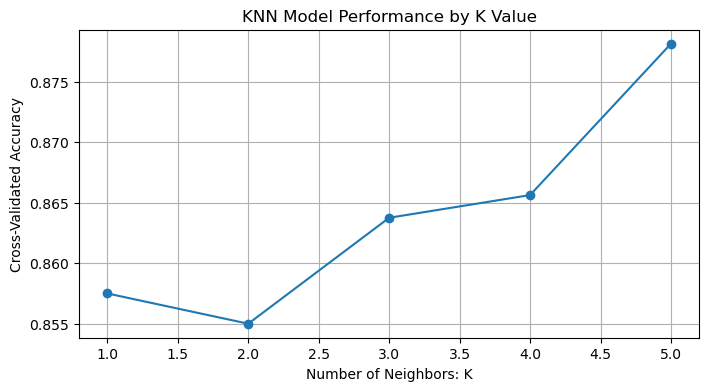

Best k: 5
Corresponding Mean Accuracy Score: 0.878125


In [87]:
# Load and split the data
X = Data[['battery_power', 'px_width', 'ram']]
y = Data['price_range']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Setting up GridSearchCV to find the best K
parameters = {'n_neighbors': range(1, 6)}  # Considering the dataset size, checking from 1 to 5
grid_search = GridSearchCV(KNeighborsClassifier(), parameters, cv=5)  # 5-fold cross-validation
grid_search.fit(X_train, y_train)

# Extracting results for analysis
k_values = [param['n_neighbors'] for param in grid_search.cv_results_['params']]
mean_test_scores = grid_search.cv_results_['mean_test_score']

# Plotting the results
plt.figure(figsize=(8, 4))
plt.plot(k_values, mean_test_scores, marker='o')
plt.xlabel('Number of Neighbors: K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Model Performance by K Value')
plt.grid(True)
plt.show()

# Best K and its performance
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print("Best k:", best_k)
print("Corresponding Mean Accuracy Score:",best_score)